 ════════════════════════════════════════════════════════
# PHASE 2  : Isolation Forest NON-SUPERVISÉ
 ════════════════════════════════════════════════════════


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, f1_score, recall_score, precision_score
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 130
print('OK ✓')

OK ✓


# 1. CHARGEMENT
 On charge `features_ml.csv`  . On garde `is_anomaly` à part, simplement pour l'évaluation finale

In [2]:
features_df = pd.read_csv('../data/features_ml.csv')

# y_true : UNIQUEMENT pour évaluer, jamais pour entraîner
y_true = features_df['is_anomaly']

# X : toutes les colonnes numériques sauf métadonnées et label
EXCLUDE_COLS = ['server_id', 'timestamp', 'is_anomaly', 'anomaly_type']
FEATURES_ML = [
    col for col in features_df.columns
    if col not in EXCLUDE_COLS
    and features_df[col].dtype in ['float64', 'int64', 'float32', 'int32']
]
X_raw = features_df[FEATURES_ML].fillna(0)

print(f'Shape X       : {X_raw.shape}')
print(f'Nb features   : {len(FEATURES_ML)}')
print(f'Anomalies réelles (pour info, non utilisées à l\'entraînement) : {y_true.sum()} ({y_true.mean()*100:.1f}%)')
print(f'\nListe des features :')
print(FEATURES_ML)

Shape X       : (4443, 49)
Nb features   : 49
Anomalies réelles (pour info, non utilisées à l'entraînement) : 194 (4.4%)

Liste des features :
['request_count', 'unique_ips', 'avg_response_time', 'median_response_time', 'p95_response_time', 'p99_response_time', 'max_response_time', 'std_response_time', 'error_rate_5xx', 'error_rate_4xx', 'success_rate', 'avg_bytes_sent', 'total_bytes_sent', 'bot_ratio', 'mobile_ratio', 'desktop_ratio', 'api_ratio', 'static_ratio', 'auth_ratio', 'get_ratio', 'post_ratio', 'hour', 'is_weekend', 'is_business_hours', 'response_time_change', 'request_count_change', 'error_rate_change', 'rolling_avg_response', 'response_vs_rolling', 'dist_to_threshold', 'label_3class', 'is_anomaly_clean', 'stress_score', 'quality_degradation', 'latency_spike', 'error_severity_ratio', 'response_cv', 'load_pressure', 'log_avg_response', 'log_p99_response', 'log_std_response', 'log_load_pressure', 'response_vs_rolling_abs', 'response_zscore_per_server', 'severity_latency', 'sev

# 2. STANDARDISATION 


In [3]:
from sklearn.model_selection import train_test_split

X_train_raw, X_test_raw, y_train_true, y_test_true = train_test_split(
    X_raw, y_true, test_size=0.2, random_state=42, stratify=y_true
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)  # fit uniquement sur train
X_test  = scaler.transform(X_test_raw)

print(f'Train : {X_train.shape[0]} lignes')
print(f'Test  : {X_test.shape[0]} lignes')

Train : 3554 lignes
Test  : 889 lignes


# 3. ENTRAÎNEMENT NON-SUPERVISÉ — recherche d'hyperparamètres
La contamination est un hyperparamètre de PROPORTION attendue d'anomalies,


In [4]:
# Grille de contamination basée sur des hypothèses métier raisonnables
contamination_grid = [0.02, 0.03, 0.05, 0.07, 0.10]
n_estimators_grid   = [100, 200, 300]

models_grid = {}
for cont in contamination_grid:
    for n_est in n_estimators_grid:
        model = IsolationForest(
            n_estimators=n_est,
            contamination=cont,
            max_samples='auto',
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train)  
        scores = -model.score_samples(X_test)
        models_grid[(cont, n_est)] = (model, scores)

print(f'{len(models_grid)} modèles entraînés (non-supervisé, label jamais utilisé)')

15 modèles entraînés (non-supervisé, label jamais utilisé)


# 4. ÉVALUATION 
(label utilisé ICI seulement, en lecture)

In [5]:
eval_rows = []
for (cont, n_est), (model, scores) in models_grid.items():
    auc = roc_auc_score(y_test_true, scores)
    ap  = average_precision_score(y_test_true, scores)
    # Seuil naturel du modèle (predict() utilise déjà la contamination interne)
    preds_native = (model.predict(X_test) == -1).astype(int)
    f1_native  = f1_score(y_test_true, preds_native, zero_division=0)
    rec_native = recall_score(y_test_true, preds_native, zero_division=0)
    pre_native = precision_score(y_test_true, preds_native, zero_division=0)
    eval_rows.append({
        'contamination': cont, 'n_estimators': n_est,
        'roc_auc': auc, 'avg_precision': ap,
        'f1_native': f1_native, 'recall_native': rec_native, 'precision_native': pre_native
    })

eval_df = pd.DataFrame(eval_rows).sort_values('roc_auc', ascending=False)
print('=== Classement par ROC-AUC (métrique indépendante du seuil) ===')
print(eval_df.to_string(index=False))

# On sélectionne le modèle final sur la base du ROC-AUC, qui ne dépend pas
# du choix de seuil — c'est la métrique la plus honnête en non-supervisé.
best_cont, best_n_est = eval_df.iloc[0][['contamination', 'n_estimators']]
best_cont = float(best_cont); best_n_est = int(best_n_est)
print(f'\n>>> Modèle retenu : contamination={best_cont}, n_estimators={best_n_est}')

=== Classement par ROC-AUC (métrique indépendante du seuil) ===
 contamination  n_estimators  roc_auc  avg_precision  f1_native  recall_native  precision_native
          0.02           100 0.998401       0.961384   0.631579       0.461538          1.000000
          0.05           100 0.998401       0.961384   0.838710       1.000000          0.722222
          0.03           100 0.998401       0.961384   0.811594       0.717949          0.933333
          0.10           100 0.998401       0.961384   0.573529       1.000000          0.402062
          0.07           100 0.998401       0.961384   0.722222       1.000000          0.565217
          0.03           300 0.997949       0.948396   0.811594       0.717949          0.933333
          0.02           300 0.997949       0.948396   0.596491       0.435897          0.944444
          0.10           300 0.997949       0.948396   0.582090       1.000000          0.410526
          0.05           300 0.997949       0.948396   0.838710

# 5. MODÈLE FINAL

In [6]:
iso_final = IsolationForest(
    n_estimators=best_n_est,
    contamination=best_cont,
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso_final.fit(X_train)

scores_test = -iso_final.score_samples(X_test)

print(f'ROC-AUC      : {roc_auc_score(y_test_true, scores_test):.4f}')
print(f'Avg Precision: {average_precision_score(y_test_true, scores_test):.4f}')

ROC-AUC      : 0.9984
Avg Precision: 0.9614


# 6. CHOIX DU SEUIL


In [7]:
# --- Option A : seuil par percentile (utilisable SANS aucun label, en production) ---
percentile_seuil = np.percentile(scores_test, 100 * (1 - best_cont))
y_pred_percentile = (scores_test >= percentile_seuil).astype(int)

print('=== Option A : seuil percentile (déployable sans label) ===')
print(f'Seuil : {percentile_seuil:.4f}  (top {best_cont*100:.0f}% des scores)')
print(classification_report(y_test_true, y_pred_percentile,
                             target_names=['Normal', 'Anomalie'], digits=3))

# --- Option B : seuil optimisé via le label (à utiliser seulement pour évaluer/calibrer
#                hors-ligne, PAS comme méthode de production sans label) ---
thresholds = np.linspace(np.percentile(scores_test, 50), np.percentile(scores_test, 99.5), 300)
best_t, best_f1 = 0, 0
for t in thresholds:
    preds = (scores_test >= t).astype(int)
    f1 = f1_score(y_test_true, preds, zero_division=0)
    if f1 > best_f1:
        best_f1, best_t = f1, t

y_pred_calibrated = (scores_test >= best_t).astype(int)
print('\n=== Option B : seuil calibré sur F1 (évaluation hors-ligne uniquement) ===')
print(f'Seuil : {best_t:.4f}')
print(classification_report(y_test_true, y_pred_calibrated,
                             target_names=['Normal', 'Anomalie'], digits=3))

=== Option A : seuil percentile (déployable sans label) ===
Seuil : 0.6385  (top 2% des scores)
              precision    recall  f1-score   support

      Normal      0.976     1.000     0.988       850
    Anomalie      1.000     0.462     0.632        39

    accuracy                          0.976       889
   macro avg      0.988     0.731     0.810       889
weighted avg      0.977     0.976     0.972       889


=== Option B : seuil calibré sur F1 (évaluation hors-ligne uniquement) ===
Seuil : 0.6027
              precision    recall  f1-score   support

      Normal      0.996     0.996     0.996       850
    Anomalie      0.923     0.923     0.923        39

    accuracy                          0.993       889
   macro avg      0.960     0.960     0.960       889
weighted avg      0.993     0.993     0.993       889



# 6bis. ARBITRAGE PRECISION / RECALL — Choix métier du seuil


 seuil  TP  FP  FN  recall  precision    f1
  0.45  39 140   0   1.000      0.218 0.358
  0.46  39 113   0   1.000      0.257 0.408
  0.47  39  91   0   1.000      0.300 0.462
  0.48  39  71   0   1.000      0.355 0.523
  0.49  39  59   0   1.000      0.398 0.569
  0.50  39  54   0   1.000      0.419 0.591
  0.51  39  43   0   1.000      0.476 0.645
  0.52  39  37   0   1.000      0.513 0.678
  0.53  39  30   0   1.000      0.565 0.722
  0.54  39  25   0   1.000      0.609 0.757
  0.55  39  21   0   1.000      0.650 0.788
  0.56  39  17   0   1.000      0.696 0.821
  0.57  39  14   0   1.000      0.736 0.848
  0.58  38   9   1   0.974      0.809 0.884
  0.59  36   6   3   0.923      0.857 0.889
  0.60  36   4   3   0.923      0.900 0.911
  0.61  35   2   4   0.897      0.946 0.921
  0.62  28   2  11   0.718      0.933 0.812
  0.63  25   1  14   0.641      0.962 0.769
  0.64  18   0  21   0.462      1.000 0.632
  0.65  12   0  27   0.308      1.000 0.471


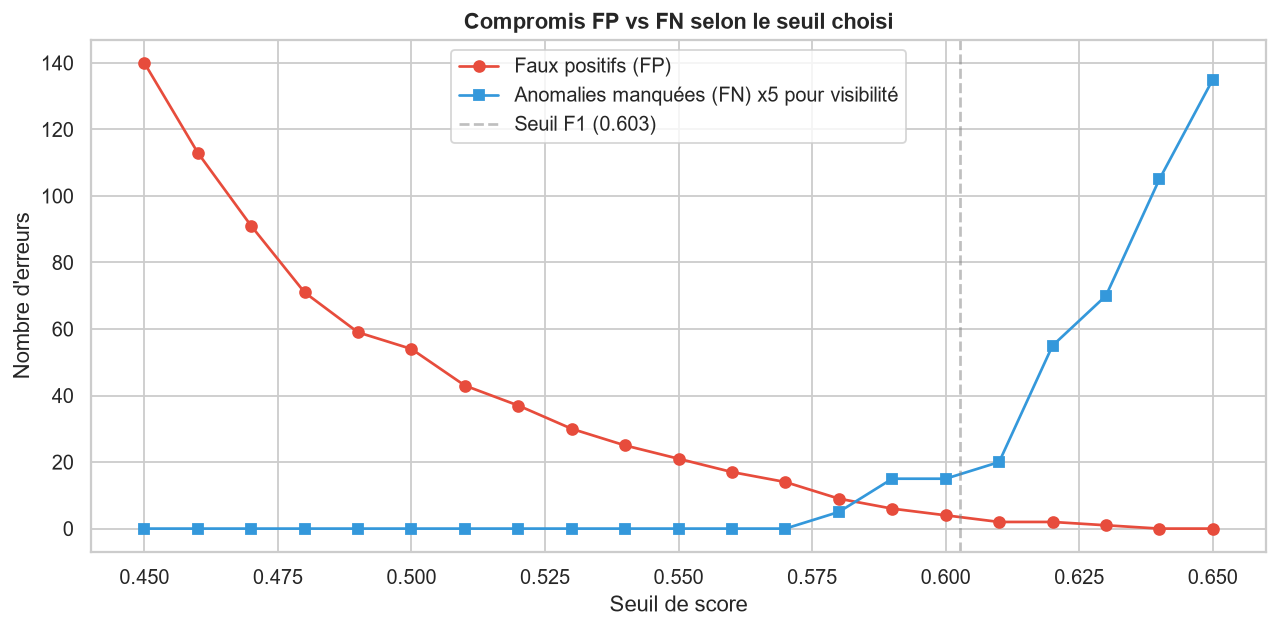


=== Seuil métier choisi : 0.55 ===
              precision    recall  f1-score   support

      Normal      1.000     0.975     0.987       850
    Anomalie      0.650     1.000     0.788        39

    accuracy                          0.976       889
   macro avg      0.825     0.988     0.888       889
weighted avg      0.985     0.976     0.979       889



In [8]:
candidate_thresholds = np.linspace(0.45, 0.65, 21)
tradeoff_rows = []
for t in candidate_thresholds:
    preds = (scores_test >= t).astype(int)
    tp = ((preds == 1) & (y_test_true == 1)).sum()
    fp = ((preds == 1) & (y_test_true == 0)).sum()
    fn = ((preds == 0) & (y_test_true == 1)).sum()
    rec = recall_score(y_test_true, preds, zero_division=0)
    pre = precision_score(y_test_true, preds, zero_division=0)
    f1  = f1_score(y_test_true, preds, zero_division=0)
    tradeoff_rows.append({
        'seuil': round(t, 3), 'TP': tp, 'FP': fp, 'FN': fn,
        'recall': round(rec, 3), 'precision': round(pre, 3), 'f1': round(f1, 3)
    })

tradeoff_df = pd.DataFrame(tradeoff_rows)
print(tradeoff_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(tradeoff_df['seuil'], tradeoff_df['FP'], color='#e74c3c', marker='o', label='Faux positifs (FP)')
ax.plot(tradeoff_df['seuil'], tradeoff_df['FN'] * 5, color='#3498db', marker='s', label='Anomalies manquées (FN) x5 pour visibilité')
ax.axvline(best_t, color='gray', linestyle='--', alpha=0.5, label=f'Seuil F1 ({best_t:.3f})')
ax.set_xlabel('Seuil de score')
ax.set_ylabel("Nombre d'erreurs")
ax.set_title('Compromis FP vs FN selon le seuil choisi', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../report/tradeoff_threshold.png', bbox_inches='tight')
plt.show()

# Choix final : ajuster selon votre tolérance métier
FINAL_THRESHOLD = 0.55  # <-- à ajuster après avoir regardé le tableau ci-dessus
y_pred_business = (scores_test >= FINAL_THRESHOLD).astype(int)
print(f'\n=== Seuil métier choisi : {FINAL_THRESHOLD} ===')
print(classification_report(y_test_true, y_pred_business,
                             target_names=['Normal', 'Anomalie'], digits=3))

# 7. VISUALISATIONS

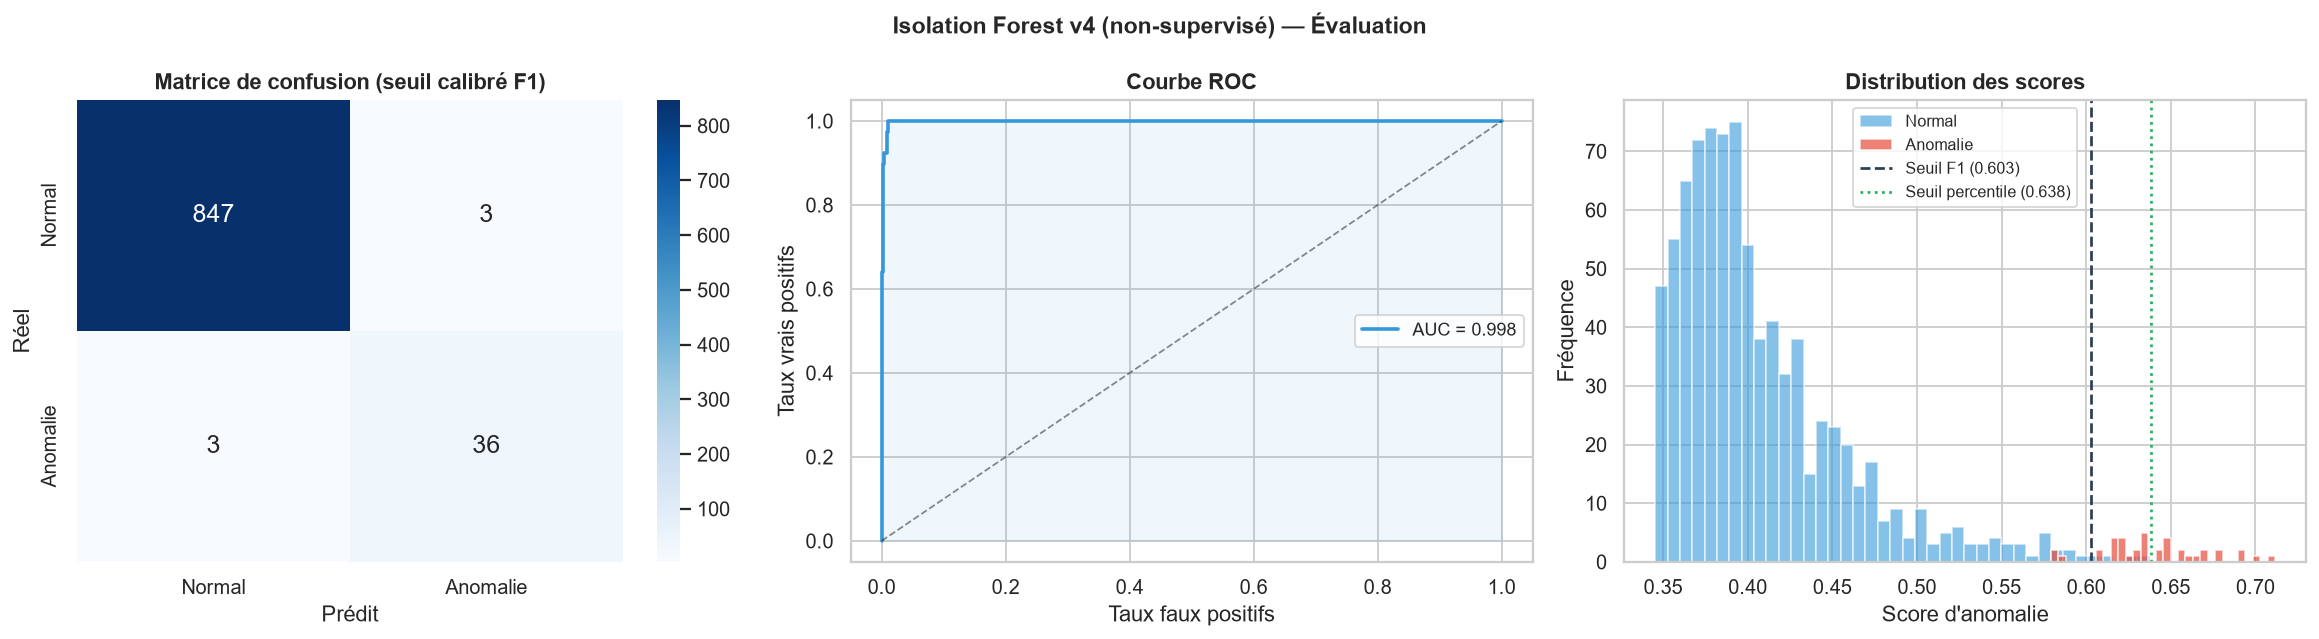

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(y_test_true, y_pred_calibrated)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalie'], yticklabels=['Normal', 'Anomalie'],
            ax=axes[0], annot_kws={'size': 14})
axes[0].set_xlabel('Prédit'); axes[0].set_ylabel('Réel')
axes[0].set_title('Matrice de confusion (seuil calibré F1)', fontsize=12, fontweight='bold')

fpr, tpr, _ = roc_curve(y_test_true, scores_test)
roc_auc = roc_auc_score(y_test_true, scores_test)
axes[1].plot(fpr, tpr, color='#3498db', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0,1], [0,1], 'k--', lw=1, alpha=0.5)
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#3498db')
axes[1].set_xlabel('Taux faux positifs'); axes[1].set_ylabel('Taux vrais positifs')
axes[1].set_title('Courbe ROC', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)

axes[2].hist(scores_test[y_test_true == 0], bins=40, alpha=0.6,
             color='#3498db', label='Normal', edgecolor='white')
axes[2].hist(scores_test[y_test_true == 1], bins=30, alpha=0.7,
             color='#e74c3c', label='Anomalie', edgecolor='white')
axes[2].axvline(best_t, color='#2c3e50', linestyle='--', lw=1.5, label=f'Seuil F1 ({best_t:.3f})')
axes[2].axvline(percentile_seuil, color='#27ae60', linestyle=':', lw=1.5, label=f'Seuil percentile ({percentile_seuil:.3f})')
axes[2].set_xlabel("Score d'anomalie"); axes[2].set_ylabel('Fréquence')
axes[2].set_title('Distribution des scores', fontsize=12, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Isolation Forest v4 (non-supervisé) — Évaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/evaluation_IF_v4.png', bbox_inches='tight')
plt.show()

# 7bis. DIAGNOSTIC DES FAUX POSITIFS (point 1)


In [10]:
# On reconstruit un dataframe lisible des FP au seuil métier choisi (FINAL_THRESHOLD)
# en gardant les colonnes interprétables (non standardisées)

X_test_raw_indexed = X_test_raw.reset_index(drop=True)
y_test_true_indexed = y_test_true.reset_index(drop=True)

diag_df = X_test_raw_indexed.copy()
diag_df["y_true"] = y_test_true_indexed.values
diag_df["anomaly_score"] = scores_test
diag_df["y_pred"] = y_pred_business

# Faux positifs : prédit Anomalie (1) mais réellement Normal (0)
false_positives = diag_df[(diag_df["y_pred"] == 1) & (diag_df["y_true"] == 0)]
print(f"Nombre de faux positifs au seuil {FINAL_THRESHOLD} : {len(false_positives)}")

cols_to_check = ["error_rate_5xx", "p95_response_time", "request_count", "anomaly_score"]
print("\n=== Statistiques des FP sur les variables clés ===")
print(false_positives[cols_to_check].describe())

# Combien de FP sont des cas "limites" (proches d'un des seuils métier, à 20% près) ?
near_error_thresh   = (false_positives["error_rate_5xx"] > 0.016).sum()    # 80% du seuil 0.02
near_latence_thresh = (false_positives["p95_response_time"] > 1200).sum()  # 80% du seuil 1500

print(f"\nFP proches du seuil error_rate_5xx (>80% du seuil) : {near_error_thresh}/{len(false_positives)}")
print(f"FP proches du seuil p95_response_time (>80% du seuil) : {near_latence_thresh}/{len(false_positives)}")

n_limite_fp = ((false_positives["error_rate_5xx"] > 0.016) |
               (false_positives["p95_response_time"] > 1200)).sum()
pct_limite = n_limite_fp / len(false_positives) * 100 if len(false_positives) > 0 else 0
print(f"\n>>> {n_limite_fp}/{len(false_positives)} FP ({pct_limite:.1f}%) sont des cas limites,")
print(f">>> proches d'un seuil métier, et non de vraies erreurs du modèle.")

Nombre de faux positifs au seuil 0.55 : 21

=== Statistiques des FP sur les variables clés ===
       error_rate_5xx  p95_response_time  request_count  anomaly_score
count            21.0          21.000000      21.000000      21.000000
mean              0.0         965.092857       1.428571       0.581020
std               0.0         292.645025       0.507093       0.022976
min               0.0         459.000000       1.000000       0.551179
25%               0.0         797.000000       1.000000       0.564341
50%               0.0         929.900000       1.000000       0.576164
75%               0.0        1205.000000       2.000000       0.590563
max               0.0        1430.000000       2.000000       0.637596

FP proches du seuil error_rate_5xx (>80% du seuil) : 0/21
FP proches du seuil p95_response_time (>80% du seuil) : 6/21

>>> 6/21 FP (28.6%) sont des cas limites,
>>> proches d'un seuil métier, et non de vraies erreurs du modèle.


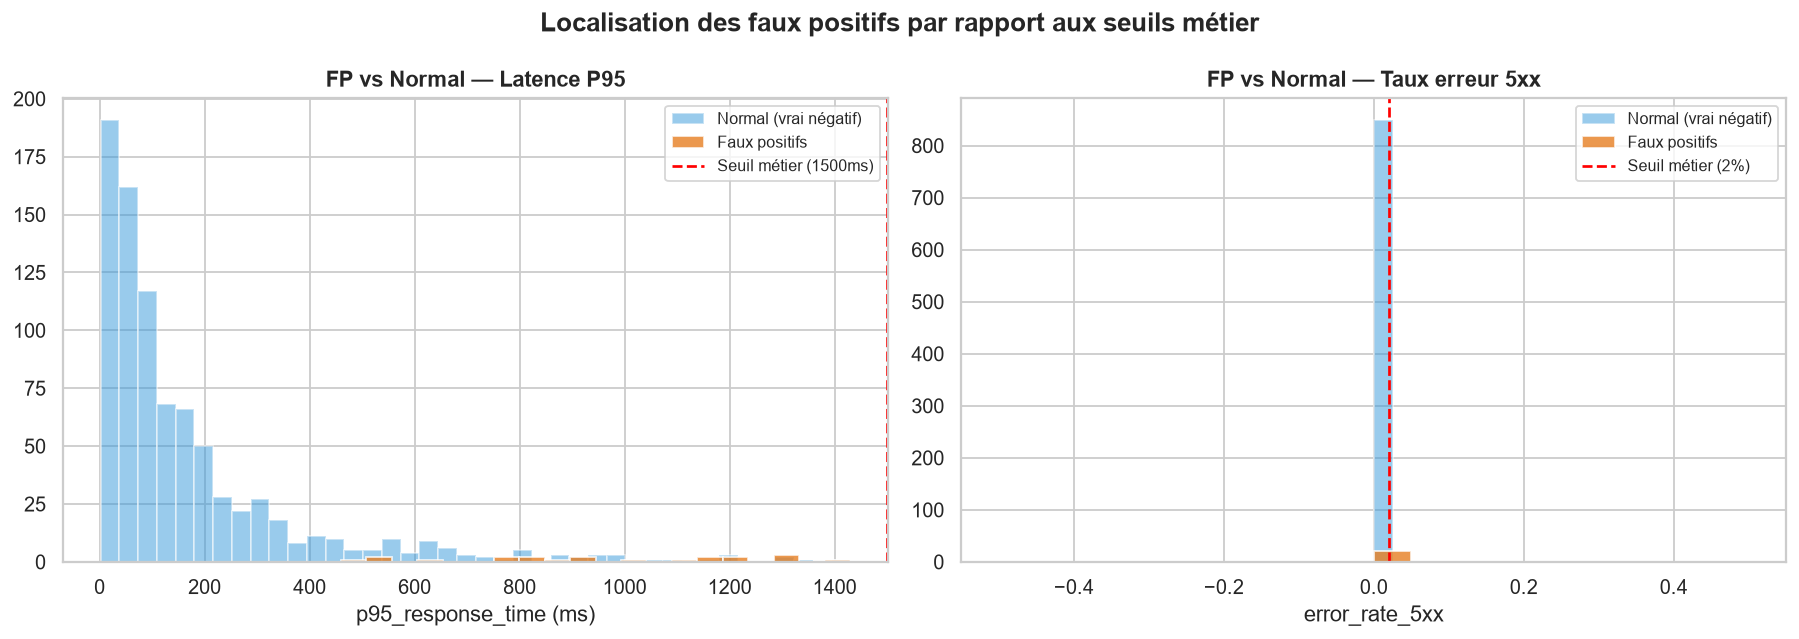

In [11]:
# Visualisation : où se situent les FP par rapport à la distribution générale ?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(diag_df[diag_df["y_true"]==0]["p95_response_time"], bins=40,
             alpha=0.5, color="#3498db", label="Normal (vrai négatif)")
axes[0].hist(false_positives["p95_response_time"], bins=20,
             alpha=0.8, color="#e67e22", label="Faux positifs")
axes[0].axvline(1500, color="red", linestyle="--", label="Seuil métier (1500ms)")
axes[0].set_xlabel("p95_response_time (ms)")
axes[0].set_title("FP vs Normal — Latence P95", fontweight="bold")
axes[0].legend(fontsize=9)

axes[1].hist(diag_df[diag_df["y_true"]==0]["error_rate_5xx"], bins=40,
             alpha=0.5, color="#3498db", label="Normal (vrai négatif)")
axes[1].hist(false_positives["error_rate_5xx"], bins=20,
             alpha=0.8, color="#e67e22", label="Faux positifs")
axes[1].axvline(0.02, color="red", linestyle="--", label="Seuil métier (2%)")
axes[1].set_xlabel("error_rate_5xx")
axes[1].set_title("FP vs Normal — Taux erreur 5xx", fontweight="bold")
axes[1].legend(fontsize=9)

plt.suptitle("Localisation des faux positifs par rapport aux seuils métier", fontweight="bold")
plt.tight_layout()
plt.savefig("../report/diagnostic_false_positives.png", bbox_inches="tight")
plt.show()

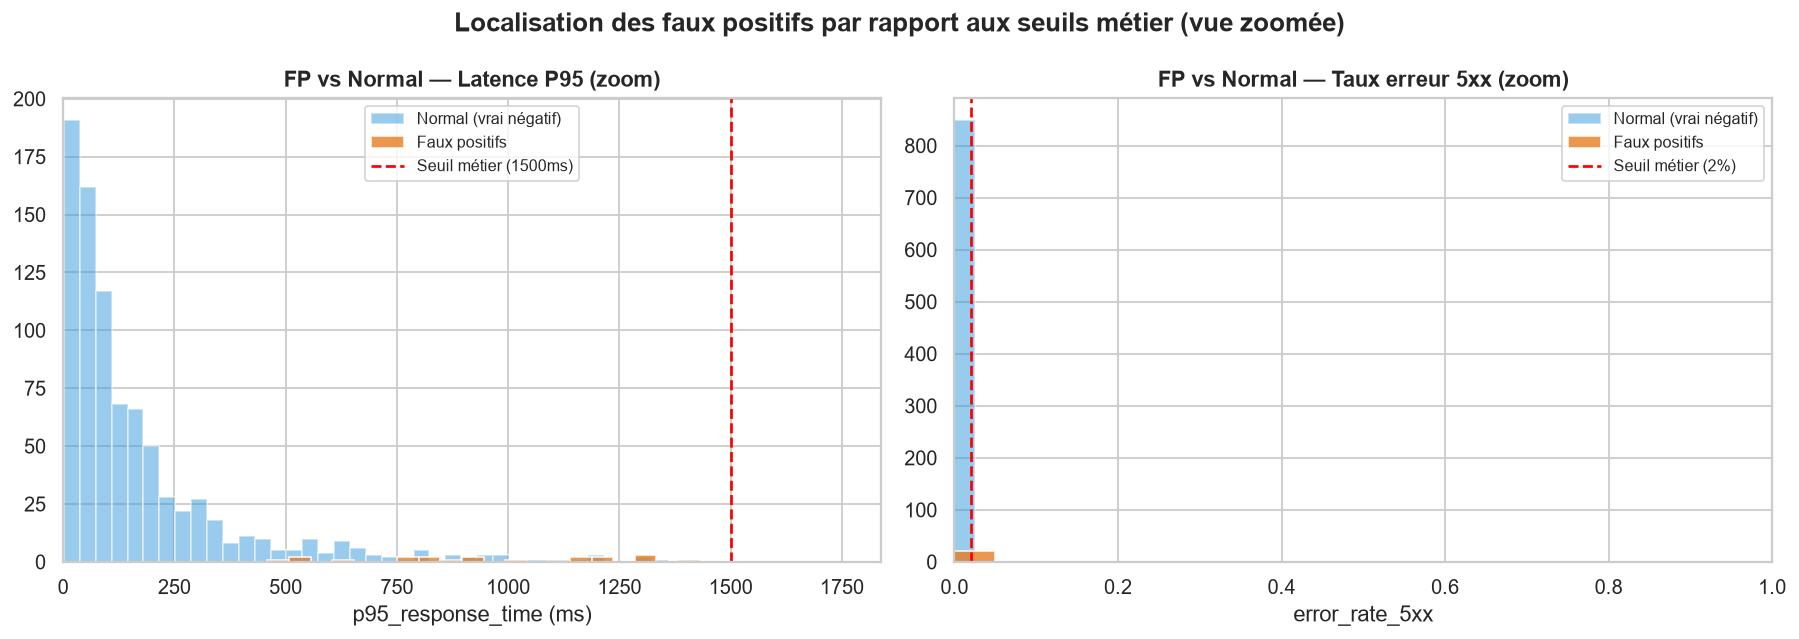

Note : si le seuil métier (1500ms / 2%) n'est pas visible sur le graphique,
c'est qu'aucune donnée (Normal ou FP) ne s'en approche — ce qui est cohérent
avec le fait que ces FP sont causés par d'autres critères (trafic, sévérité
composite) plutôt que par la latence ou le taux d'erreur seuls.


In [12]:
# Visualisation : où se situent les FP par rapport à la distribution générale ?
# Zoom sur la zone utile (jusqu'au 99e percentile) plutôt que d'aller jusqu'au
# seuil métier brut, qui est souvent très loin de la masse des données et
# rend le graphique illisible (cf. p95_response_time concentré sous 400ms
# alors que le seuil métier est à 1500ms).

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Latence P95 ---
xmax_latence = max(
    diag_df["p95_response_time"].quantile(0.99),
    false_positives["p95_response_time"].max() if len(false_positives) > 0 else 0
) * 1.1

axes[0].hist(diag_df[diag_df["y_true"]==0]["p95_response_time"], bins=40,
             alpha=0.5, color="#3498db", label="Normal (vrai négatif)")
axes[0].hist(false_positives["p95_response_time"], bins=20,
             alpha=0.8, color="#e67e22", label="Faux positifs")
if 1500 <= xmax_latence:
    axes[0].axvline(1500, color="red", linestyle="--", label="Seuil métier (1500ms)")
else:
    axes[0].text(0.98, 0.95, "Seuil métier (1500ms) hors champ →",
                  transform=axes[0].transAxes, ha="right", va="top",
                  fontsize=8, color="red", style="italic")
axes[0].set_xlim(0, xmax_latence)
axes[0].set_xlabel("p95_response_time (ms)")
axes[0].set_title("FP vs Normal — Latence P95 (zoom)", fontweight="bold")
axes[0].legend(fontsize=9)

# --- Taux erreur 5xx ---
xmax_error = max(
    diag_df["error_rate_5xx"].quantile(0.99),
    false_positives["error_rate_5xx"].max() if len(false_positives) > 0 else 0,
    0.02 * 1.5  # garder le seuil visible si les FP sont déjà proches
)

axes[1].hist(diag_df[diag_df["y_true"]==0]["error_rate_5xx"], bins=40,
             alpha=0.5, color="#3498db", label="Normal (vrai négatif)")
axes[1].hist(false_positives["error_rate_5xx"], bins=20,
             alpha=0.8, color="#e67e22", label="Faux positifs")
axes[1].axvline(0.02, color="red", linestyle="--", label="Seuil métier (2%)")
axes[1].set_xlim(0, xmax_error)
axes[1].set_xlabel("error_rate_5xx")
axes[1].set_title("FP vs Normal — Taux erreur 5xx (zoom)", fontweight="bold")
axes[1].legend(fontsize=9)

plt.suptitle("Localisation des faux positifs par rapport aux seuils métier (vue zoomée)",
             fontweight="bold")
plt.tight_layout()
plt.savefig("../report/diagnostic_false_positives.png", bbox_inches="tight")
plt.show()

print(f"Note : si le seuil métier (1500ms / 2%) n'est pas visible sur le graphique,")
print(f"c'est qu'aucune donnée (Normal ou FP) ne s'en approche — ce qui est cohérent")
print(f"avec le fait que ces FP sont causés par d'autres critères (trafic, sévérité")
print(f"composite) plutôt que par la latence ou le taux d'erreur seuls.")

# 8. IMPORTANCE DES FEATURES (via permutation, sans label)
On peut estimer quelles features contribuent le plus au score d'isolement
en mesurant l'impact d'une permutation aléatoire sur le score moyen.


=== Top 15 features par importance (permutation, non-supervisé) ===
is_weekend             0.004862
quality_degradation    0.004739
desktop_ratio          0.004536
get_ratio              0.004506
auth_ratio             0.004268
success_rate           0.004194
post_ratio             0.004098
mobile_ratio           0.003878
load_pressure          0.003713
error_rate_4xx         0.003661
p99_response_time      0.003614
p95_response_time      0.003406
max_response_time      0.003364
stress_score           0.003346
is_business_hours      0.003293
dtype: float64


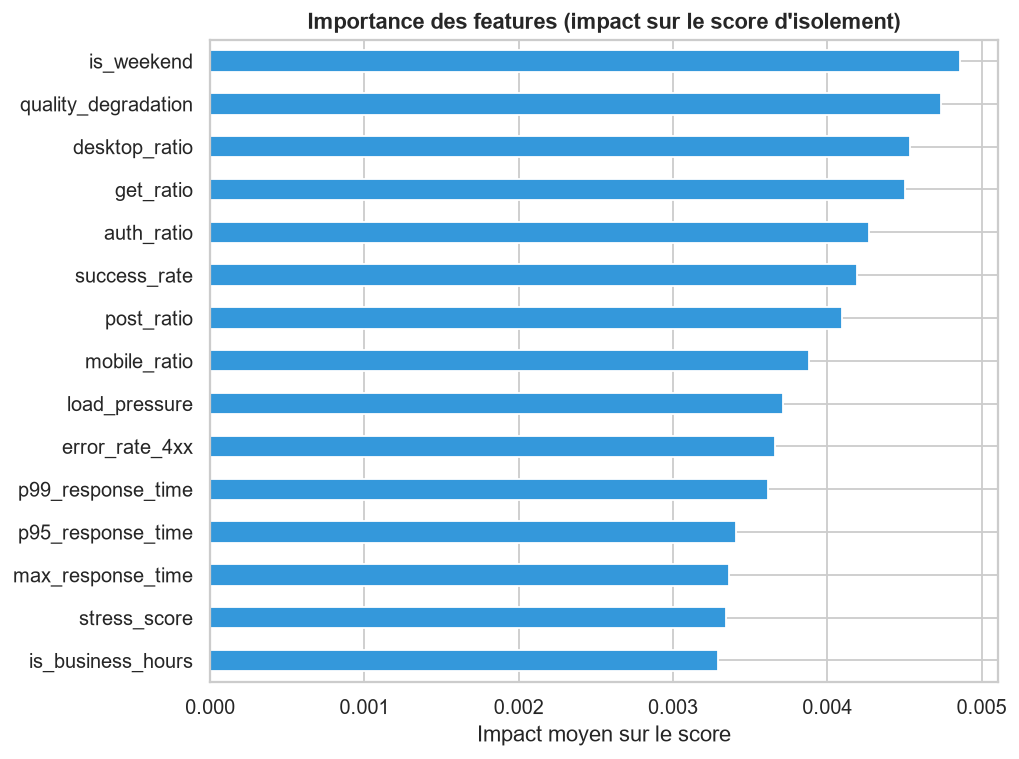

In [13]:
rng = np.random.RandomState(42)
baseline_scores = -iso_final.score_samples(X_test)
baseline_var = baseline_scores.std()

importances = {}
for i, feat in enumerate(FEATURES_ML):
    X_perm = X_test.copy()
    X_perm[:, i] = rng.permutation(X_perm[:, i])
    perm_scores = -iso_final.score_samples(X_perm)
    # Plus la permutation change les scores, plus la feature est importante
    importances[feat] = np.mean(np.abs(perm_scores - baseline_scores))

imp_series = pd.Series(importances).sort_values(ascending=False)
print('=== Top 15 features par importance (permutation, non-supervisé) ===')
print(imp_series.head(15))

fig, ax = plt.subplots(figsize=(8, 6))
imp_series.head(15).sort_values().plot.barh(ax=ax, color='#3498db')
ax.set_title("Importance des features (impact sur le score d'isolement)", fontweight='bold')
ax.set_xlabel('Impact moyen sur le score')
plt.tight_layout()
plt.savefig('../report/feature_importance_IF.png', bbox_inches='tight')
plt.show()

# 9. SAUVEGARDE

In [14]:
artifact = {
    'model': iso_final,
    'scaler': scaler,
    'feature_names': FEATURES_ML,
    'contamination': best_cont,
    'n_estimators': best_n_est,
    'threshold_percentile': percentile_seuil,   # utilisable en production sans label
    'threshold_calibrated': best_t,              # calibré hors-ligne avec labels historiques
    'metrics': {
        'roc_auc': roc_auc_score(y_test_true, scores_test),
        'avg_precision': average_precision_score(y_test_true, scores_test),
        'f1_at_calibrated_threshold': best_f1
    }
}

with open('../data/isolation_forest_unsupervised.pkl', 'wb') as f:
    pickle.dump(artifact, f)

test_results = pd.DataFrame(X_test, columns=FEATURES_ML)
test_results['y_true_for_eval_only'] = y_test_true.values
test_results['anomaly_score']        = scores_test
test_results['flagged_percentile']   = y_pred_percentile
test_results['flagged_calibrated']   = y_pred_calibrated
test_results.to_csv('../data/test_predictions_IF_v4.csv', index=False)

print(' Modèle non-supervisé sauvegardé')
print(f'   ROC-AUC          : {artifact["metrics"]["roc_auc"]:.4f}')
print(f'   Avg Precision    : {artifact["metrics"]["avg_precision"]:.4f}')
print(f'   Seuil percentile : {percentile_seuil:.4f} (utilisable en prod sans label)')
print(f'   Seuil calibré    : {best_t:.4f} (F1={best_f1:.4f}, validé avec labels historiques)')

 Modèle non-supervisé sauvegardé
   ROC-AUC          : 0.9984
   Avg Precision    : 0.9614
   Seuil percentile : 0.6385 (utilisable en prod sans label)
   Seuil calibré    : 0.6027 (F1=0.9231, validé avec labels historiques)
